# <center> <img src="../img/ITESOLogo.png" alt="ITESO" width="480" height="130"> </center>
# <center> **Departamento de Electrónica, Sistemas e Informática** </center>
---
## <center> **Procesamiento de Datos Masivos (Big Data)** </center>
---
### <center> **Spring 2026** </center>
---
### <center> **Lab 06** </center>
---
<br>
    <center>Luis Roberto Navarro Quinn - 740250 </center>
    <center>Santiago Ortíz Soto - 740412 </center>
    <center>Saul Razo Magallanes - 739974</center>
    <center>Ingeniería en Sistemas Computacionales</center>
    <center><strong>Profesor:</strong> Pablo Camarillo Ramírez</center>
    <center><strong>Fecha:</strong> 22/03/2026</center>

In [2]:
!pip install graphframes

In [1]:
from pcamarillor.spark_utils import SparkUtils
import pyspark.sql.functions as F

neo4j_connector = "org.neo4j:neo4j-connector-apache-spark_2.13:5.3.10_for_spark_3,io.graphframes:graphframes-spark3_2.13:0.9.0-spark3.5"
su = SparkUtils("Lab06 - Videogames Graph", "spark://spark-master:7077", spark_packages=neo4j_connector)
su.spark

:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /root/.ivy2.5.2/cache
The jars for the packages stored in: /root/.ivy2.5.2/jars
org.neo4j#neo4j-connector-apache-spark_2.13 added as a dependency
io.graphframes#graphframes-spark3_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-ed27c7ef-c00e-4897-a76d-06291bf46e9c;1.0
	confs: [default]
	found org.neo4j#neo4j-connector-apache-spark_2.13;5.3.10_for_spark_3 in central
	found org.neo4j#neo4j-connector-apache-spark_2.13_common;5.3.10_for_spark_3 in central
	found org.neo4j#caniuse-core;1.3.0 in central
	found org.neo4j#caniuse-api;1.3.0 in central
	found org.jetbrains.kotlin#kotlin-stdlib;2.1.20 in central
	found org.jetbrains#annotations;13.0 in central
	found org.neo4j#caniuse-neo4j-detection;1.3.0 in central
	found org.neo4j.driver#neo4j-java-driver-slim;4.4.21 in central
	found org.reactivestreams#reactiv

### Dataset

In [2]:
EDGES_PATH = "/opt/spark/work-dir/data/videogames/rec-amz-Video-Games.edges"

games_df = (
    su.spark.read
    .option("header", "false")
    .option("sep", ",")
    .csv(EDGES_PATH)
    .toDF("user_id", "game_id", "rating", "timestamp")
    .dropna()
)

games_df.show(10, truncate=False)

+--------------+----------+------+----------+
|user_id       |game_id   |rating|timestamp |
+--------------+----------+------+----------+
|AB9S9279OZ3QO |0078764343|5.0   |1373155200|
|A24SSUT5CSW8BH|0078764343|5.0   |1377302400|
|AK3V0HEBJMQ7J |0078764343|4.0   |1372896000|
|A10BECPH7W8HM7|043933702X|5.0   |1404950400|
|A2PRV9OULX1TWP|043933702X|5.0   |1386115200|
|AE7GUHCDQQ4UI |043933702X|1.0   |1366156800|
|A48ABFDDRMKI8 |043933702X|5.0   |1374192000|
|A26B0P6K95SIKW|0439339960|3.0   |1288569600|
|AZ3UWOC8QSO6C |0439339987|5.0   |1366848000|
|A182S3ANC0W7DL|0439342260|4.0   |1355875200|
+--------------+----------+------+----------+
only showing top 10 rows


### Data Ingestion. 

In [3]:
from graphframes import GraphFrame

vertices = (
    games_df.selectExpr("user_id as id", "'user' as type")
    .union(games_df.selectExpr("game_id as id", "'game' as type"))
    .distinct()
)

edges = games_df.selectExpr("user_id as src", "game_id as dst", "cast(rating as double) as rating")

g = GraphFrame(vertices, edges)
g.vertices.show()
g.edges.show()

/opt/spark/python/pyspark/sql/classic/dataframe.py:146: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(
                                                                                

+--------------+----+
|            id|type|
+--------------+----+
| AE7GUHCDQQ4UI|user|
|A26B0P6K95SIKW|user|
|A182S3ANC0W7DL|user|
|A1T98OCCYW6OBI|user|
|A1TBUSGCBTXWFC|user|
|A366EUKI8WMGYB|user|
|A129SW886TYQ6H|user|
|A2M64UKVOU9CWU|user|
|A10N7L0GMRODUO|user|
| AFWPLXT2OD6H1|user|
|A2890J1FHE76RY|user|
| AJRHPTQ7TXPD6|user|
|A2NQXA21O64HDZ|user|
|A261CI99KET69W|user|
|A214Z566V6QEDF|user|
|A1NC9PQCE3NOGA|user|
|A27QRTHZLBA61M|user|
| ADOCLYEFV2PKH|user|
| A8SSL0QMV2VY1|user|
| AA9LU15A9PX9E|user|
+--------------+----+
only showing top 20 rows
+--------------+----------+------+
|           src|       dst|rating|
+--------------+----------+------+
| AB9S9279OZ3QO|0078764343|   5.0|
|A24SSUT5CSW8BH|0078764343|   5.0|
| AK3V0HEBJMQ7J|0078764343|   4.0|
|A10BECPH7W8HM7|043933702X|   5.0|
|A2PRV9OULX1TWP|043933702X|   5.0|
| AE7GUHCDQQ4UI|043933702X|   1.0|
| A48ABFDDRMKI8|043933702X|   5.0|
|A26B0P6K95SIKW|0439339960|   3.0|
| AZ3UWOC8QSO6C|0439339987|   5.0|
|A182S3ANC0W7DL|0439342260|

### Graph Analysis. 

#### PageRank

In [4]:
results = g.pageRank(resetProbability=0.15, maxIter=10)

results.vertices \
    .filter("type = 'game'") \
    .select("id", "type", "pagerank") \
    .orderBy("pagerank", ascending=False) \
    .show(20, truncate=False)

/opt/spark/python/pyspark/sql/classic/dataframe.py:128: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")
                                                                                

+----------+----+------------------+
|id        |type|pagerank          |
+----------+----+------------------+
|B00DJFIMW6|game|7285.526431395484 |
|B00BGA9WK2|game|2645.507195083908 |
|B00FAX6XQC|game|2547.3341328377564|
|B009KS4XRO|game|2501.0385889444806|
|B0055SWM08|game|1989.4563258041183|
|B00CSR2J9I|game|1964.373283273377 |
|B002VBWIP6|game|1857.1934441848766|
|B0015AARJI|game|1408.3694893308366|
|B000FKBCX4|game|1243.5554664378442|
|B00178630A|game|1230.274656615952 |
|B007VTVRFA|game|1206.0855893139276|
|B00AIUUXHC|game|1173.889544941537 |
|B003VANOFY|game|986.3206066999797 |
|B007FTE2VW|game|984.3404153958518 |
|B000B9RI14|game|933.3473057681464 |
|B00EF1OGOG|game|813.309107754935  |
|B005EQE0YM|game|789.8962020979171 |
|B0009VXBAQ|game|759.9537257156875 |
|B0029LJIFG|game|752.2411136270933 |
|B00AW3FDIO|game|740.7225573743946 |
+----------+----+------------------+
only showing top 20 rows


#### Label Propagation

In [5]:
lpa = g.labelPropagation(maxIter=5)
lpa.show()

/opt/spark/python/pyspark/sql/classic/dataframe.py:128: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")
[Stage 190:=============================================>           (4 + 1) / 5]

+--------------------+----+-----------+
|                  id|type|      label|
+--------------------+----+-----------+
|          043933702X|game|25769804420|
|          0439671418|game| 8589972610|
|          0439900581|game|17179871748|
|          0545115507|game|      55201|
|          0700026657|game| 8590005570|
|          1886846758|game|17179911574|
|          7293000936|game| 8590098049|
|          7542614444|game|25769958148|
|          9078439122|game|34359872010|
|          9861064222|game|17179908478|
|          986118452X|game| 8590070871|
|          9861767304|game| 8589942402|
|          986325083X|game|25769883582|
|          9941113300|game|      94401|
|A0009878M2RGMMHGJH39|user|     169495|
|A00101961G0VS92WD...|user| 8590100259|
|A001147626R4BL248...|user|25769977765|
|A0011756FPL8K71Q5TAQ|user|34359907769|
|A00230923E4Y7VHWZ...|user| 8590107813|
|A00338543M2OZPUWO...|user|     172460|
+--------------------+----+-----------+
only showing top 20 rows


#### Triangle Counting

In [4]:
triangle_count = g.triangleCount()
triangle_count.show()

/opt/spark/python/pyspark/sql/classic/dataframe.py:128: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")
[Stage 108:=============================================>           (4 + 1) / 5]

+-----+--------------+----+
|count|            id|type|
+-----+--------------+----+
|    0| AE7GUHCDQQ4UI|user|
|    0|A1TBUSGCBTXWFC|user|
|    0|A129SW886TYQ6H|user|
|    0| AFWPLXT2OD6H1|user|
|    0|A26B0P6K95SIKW|user|
|    0|A366EUKI8WMGYB|user|
|    0|A10N7L0GMRODUO|user|
|    0|A261CI99KET69W|user|
|    0|A214Z566V6QEDF|user|
|    0|A182S3ANC0W7DL|user|
|    0|A2M64UKVOU9CWU|user|
|    0|A2890J1FHE76RY|user|
|    0| AJRHPTQ7TXPD6|user|
|    0|A1NC9PQCE3NOGA|user|
|    0|A27QRTHZLBA61M|user|
|    0| AA9LU15A9PX9E|user|
|    0|A1T98OCCYW6OBI|user|
|    0|A2NQXA21O64HDZ|user|
|    0| ADOCLYEFV2PKH|user|
|    0| A8SSL0QMV2VY1|user|
+-----+--------------+----+
only showing top 20 rows


#### Degree Distribution

#### InDegree

In [5]:
in_deg = g.inDegrees.join(vertices, "id")
in_deg.show()

+----------+--------+----+
|        id|inDegree|type|
+----------+--------+----+
|0439342260|       1|game|
|0439374391|       1|game|
|0439394422|       2|game|
|0439591538|       2|game|
|0439715571|       2|game|
|0700026355|       2|game|
|0700099867|      79|game|
|1886846774|       5|game|
|3866810067|       8|game|
|7100027950|      32|game|
|7118021156|       2|game|
|7532724301|       1|game|
|7800405761|       1|game|
|8176503290|      14|game|
|9081335219|       3|game|
|9576754267|       1|game|
|9576991803|       1|game|
|9620077660|       6|game|
|9624516766|       2|game|
|9625992480|       1|game|
+----------+--------+----+
only showing top 20 rows


#### OutDegree

In [6]:
out_deg = g.outDegrees.join(vertices, "id")
out_deg.show()

[Stage 121:======================================>                  (2 + 1) / 3]

+--------------------+---------+----+
|                  id|outDegree|type|
+--------------------+---------+----+
|A0002090WKEMAO8KOWKM|        1|user|
|A00063061AK7XBIZL...|        1|user|
|A00089163LKXK4V19...|        1|user|
|A00096001PYDTZQQ4...|        2|user|
|A0009878M2RGMMHGJH39|        1|user|
|A00101847G3FJTWYGNQA|        3|user|
|A00101961G0VS92WD...|        1|user|
|A001147626R4BL248...|        1|user|
|A0011756FPL8K71Q5TAQ|        2|user|
|A001412229RSF8NQJ...|        2|user|
|A00158021VAJ9275D...|        1|user|
|A00160082V0HQVAXB...|        1|user|
|A00166281YWM98A3S...|        3|user|
|A00190541RH03G6MZ...|        1|user|
|A00230923E4Y7VHWZ...|        1|user|
|A002439424KGHR3LZ...|        1|user|
|A00278362652PLQL0...|        1|user|
|A0033772XS33OKK28RIW|        1|user|
|A00338543M2OZPUWO...|        1|user|
|A00416781KPR6K34D...|        1|user|
+--------------------+---------+----+
only showing top 20 rows


### Writing Data in Neo4j. 

In [7]:
# Utilicé una muestra reducida del dataset (limit=500) debido a limitaciones
# de memoria en mi equipo local.
games_df_short = games_df.limit(500)

vertices = (
    games_df_short.selectExpr("user_id as id", "'user' as type")
    .union(games_df_short.selectExpr("game_id as id", "'game' as type"))
    .distinct()
)

edges = games_df_short.selectExpr("user_id as src", "game_id as dst", "cast(rating as double) as rating")

g_short = GraphFrame(vertices, edges)

In [6]:
neo4j_url    = "bolt://neo4j-iteso:7687"
neo4j_user   = "neo4j"
neo4j_passwd = "neo4j@1234"

# User
g_short.vertices.filter("type = 'user'").write \
    .format("org.neo4j.spark.DataSource") \
    .mode("Overwrite") \
    .option("url", neo4j_url) \
    .option("authentication.basic.username", neo4j_user) \
    .option("authentication.basic.password", neo4j_passwd) \
    .option("labels", ":User") \
    .option("node.keys", "id") \
    .save()
user_count = g_short.vertices.filter("type = 'user'").count()
print(f"{user_count} User nodes wrote in Neo4j")

# Game
g_short.vertices.filter("type = 'game'").write \
    .format("org.neo4j.spark.DataSource") \
    .mode("Overwrite") \
    .option("url", neo4j_url) \
    .option("authentication.basic.username", neo4j_user) \
    .option("authentication.basic.password", neo4j_passwd) \
    .option("labels", ":Game") \
    .option("node.keys", "id") \
    .save()
game_count = g_short.vertices.filter("type = 'game'").count()
print(f"{game_count} Game nodes wrote in Neo4j")

# RATED
g_short.edges.write \
    .format("org.neo4j.spark.DataSource") \
    .mode("Overwrite") \
    .option("url", neo4j_url) \
    .option("authentication.basic.username", neo4j_user) \
    .option("authentication.basic.password", neo4j_passwd) \
    .option("relationship", "RATED") \
    .option("relationship.save.strategy", "keys") \
    .option("relationship.source.labels", ":User") \
    .option("relationship.source.save.mode", "match") \
    .option("relationship.source.node.keys", "src:id") \
    .option("relationship.target.labels", ":Game") \
    .option("relationship.target.save.mode", "match") \
    .option("relationship.target.node.keys", "dst:id") \
    .save()
edge_count = g_short.edges.count()
print(f"{edge_count} edges wrote in Neo4j")

499 User nodes wrote in Neo4j
59 Game nodes wrote in Neo4j


500 edges wrote in Neo4j


### Querying the Graph. 

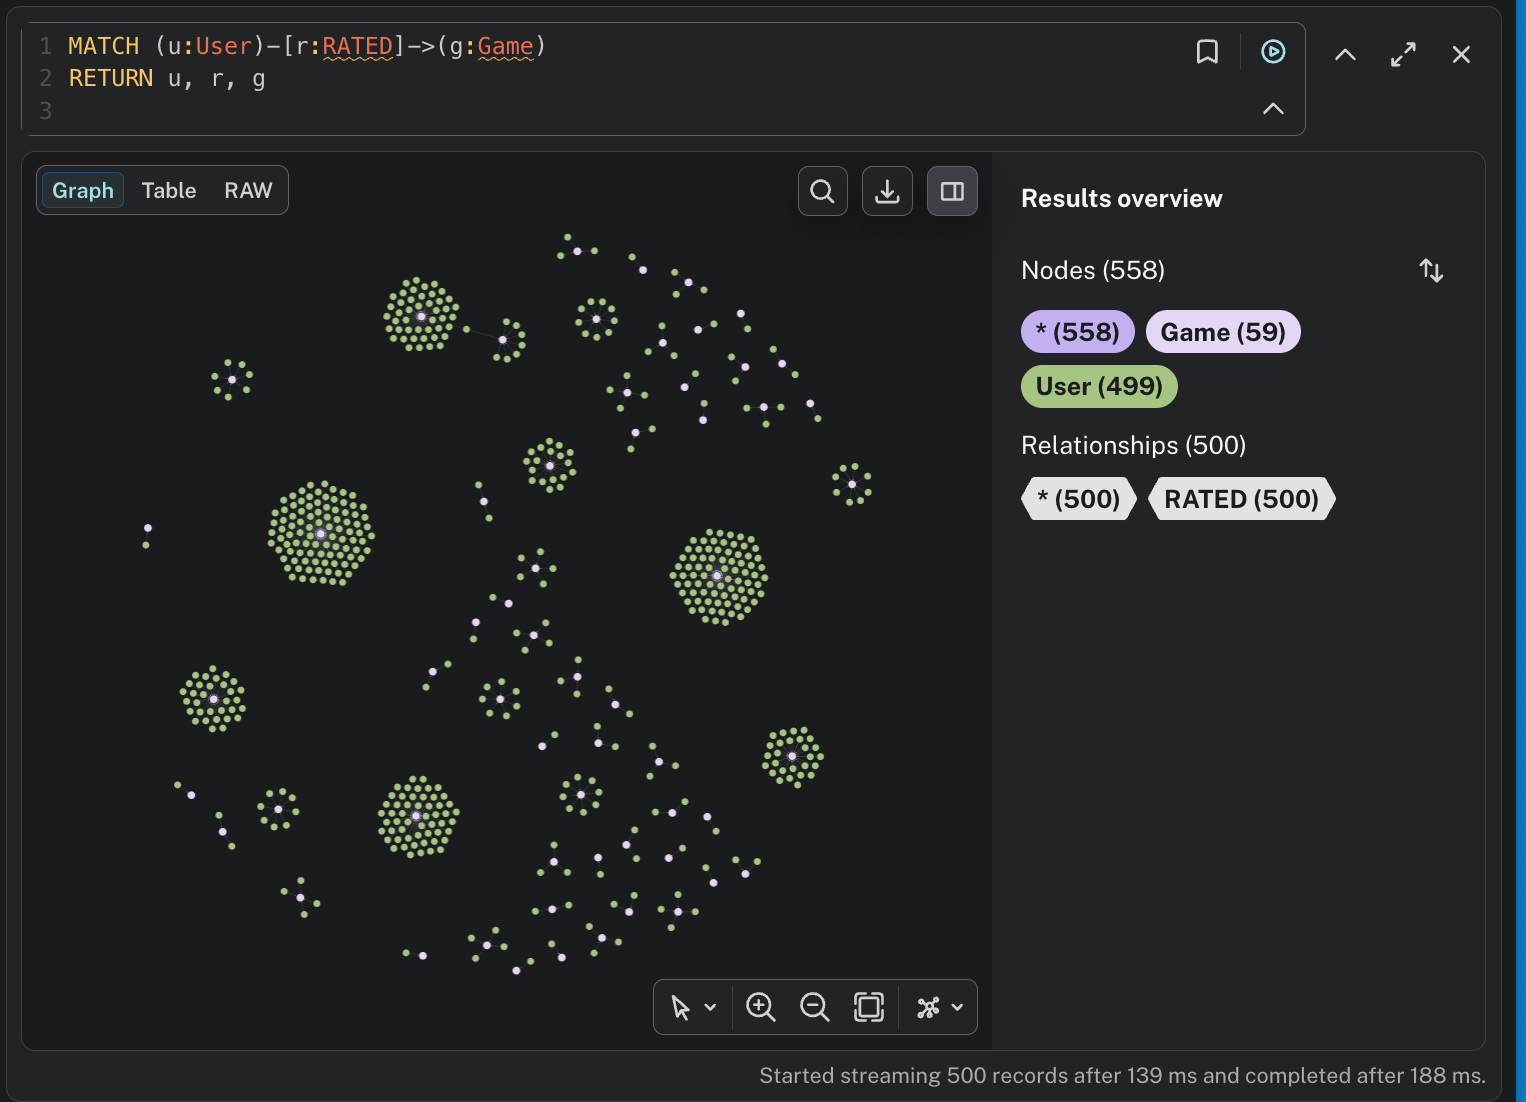

su._spark.stop()